In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



   Body Size  Body Weight  Height  Bone Structure  Complexion  \
0          1            1       1               2           2   
1          1            1       0               1           1   
2          0            1       1               1           1   
3          0            1       0               0           1   
4          2            1       0               1           0   

   General feel of skin  Texture of Skin  Hair Color  Appearance of Hair  \
0                     0                0           0                   1   
1                     0                2           1                   0   
2                     1                2           0                   0   
3                     0                2           0                   1   
4                     1                2           0                   0   

   Shape of face  ...  Eyelashes  Blinking of Eyes  Cheeks  Nose  \
0              0  ...          1                 1       0     2   
1              0

KeyboardInterrupt: 

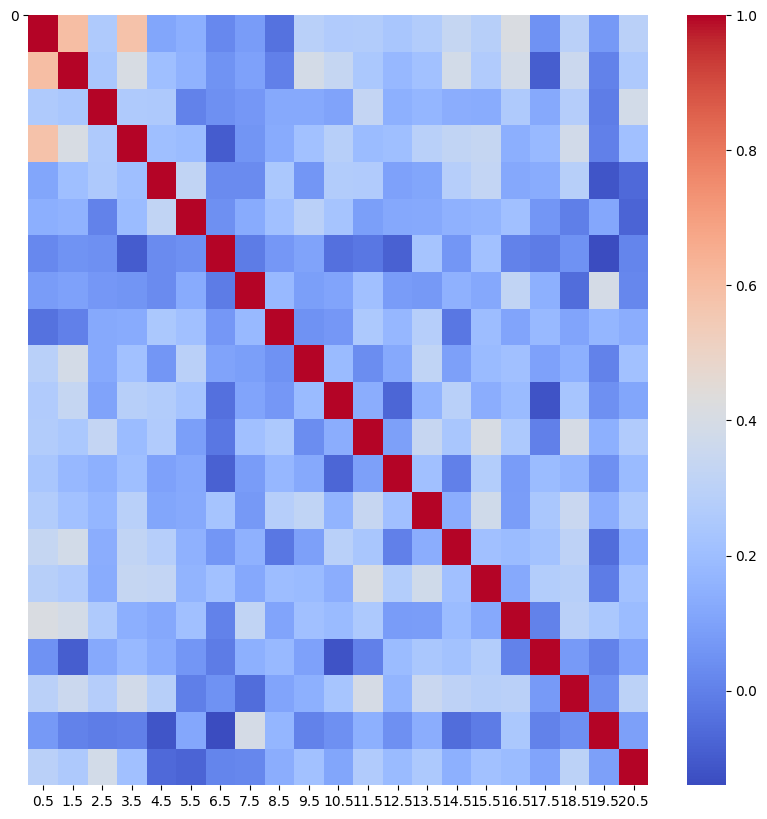

In [ ]:
data = pd.read_csv('/content/data.csv')

print(data.head())
print(data.tail())
plt.figure(figsize=(10, 10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df = pd.read_csv('/content/Prakriti.csv')
print(df)

In [ ]:
data = pd.read_csv('Prakriti.csv')

print(data.info())


**Random Forest Classifier**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load your dataset
data = pd.read_csv('Prakriti.csv')
data['combined_text'] = data.apply(lambda row: ' '.join(row.values.astype(str)), axis=1)

# Define the features and target
X = data['combined_text']
y = data['Dosha']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert the text data to numerical using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Apply RandomOverSampler to balance the dataset
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_tfidf, y_train)


# Train Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

# Predict and evaluate Random Forest model
y_pred_rf = rf_model.predict(X_test_tfidf)
print("\nRandom Forest Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)}")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

**SVM Implementation**



In [ ]:
data = pd.read_csv('Prakriti.csv')
data['combined_text'] = data.apply(lambda row: ' '.join(row.values.astype(str)), axis=1)

# Define the features and target
X = data['combined_text']
y = data['Dosha']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert the text data to numerical using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Apply RandomOverSampler to balance the dataset
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_tfidf, y_train)

# Train SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_resampled, y_train_resampled)

# Predict and evaluate SVM model
y_pred_svm = svm_model.predict(X_test_tfidf)
print("SVM Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm)}")
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))


**K Neighbours classifier**

In [ ]:
data = pd.read_csv('Prakriti.csv')

# Assume the dataset has 'text' and 'prakriti' columns
X = data['Complexion'] + " " + data['Texture of Skin'] + " " + data['Lips'] + " " + data['Nails']  + " " +data['Appetite']  + " " + data['Shape of face'] + "  "+data['Hair Color'] # Add as many text fields as needed
y = data['Dosha']

# Convert text data into numerical features using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_features = vectorizer.fit_transform(X)

# Encode target variable if necessary
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_features, y_encoded, test_size=0.3, random_state=42)

# Initialize and train KNN model
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

# Compute the confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

accuracy = accuracy_score(y_test, y_pred_knn)
print(f'Accuracy: {accuracy*100 : 2f}')

# Print classification report
report = classification_report(y_test, y_pred_knn)
print(f'Classification Report:\n{report}')



# Plot confusion matrix as heatmap
plt.figure(figsize=(2,2))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('KNN Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
data = pd.read_csv('/content/Prakriti.csv')

data['combined_text'] = data['Complexion'] + " " + data['Texture of Skin'] + " " + data['Lips'] + " " + data['Nails']  + " " +data['Appetite']  + " " + data['Shape of face'] + "  "+data['Hair Color'] # Add as many text fields as needed

# Define features and target variable
X = data['combined_text']
y = data['Dosha']

# Convert text data into numerical features using TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)  # Adjust parameters as needed
X_features = vectorizer.fit_transform(X)

# Encode target variable if necessary
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_features, y_encoded, test_size=0.3, random_state=42)

# Initialize Multinomial Naive Bayes model
model = MultinomialNB()

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)



# Plot confusion matrix as heatmap
plt.figure(figsize=(10, 7))  # Set figure size if needed
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

**SMOTE Technique:**

In [ ]:
from imblearn.over_sampling import SMOTE
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer

# Load your dataset
df = pd.read_csv('/content/Prakriti.csv')

# Encode categorical columns if necessary
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le  # Save encoder for inverse transform if needed

# Assuming 'Dosha' is your target column and 'combined_text' is a text feature
X = df.drop(['Dosha'], axis=1)  # Features (adjust if 'combined_text' needs to be included)
y = df['Dosha']                 # Target

# Check the distribution of classes
print("Class distribution before SMOTE:")
print(y.value_counts())

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to the training set
smote = SMOTE(random_state=42)

# Check if X_train is a DataFrame and handle text columns appropriately
if isinstance(X_train, pd.DataFrame):
    # If you have text columns, preprocess them separately
    numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
    text_features = X_train.select_dtypes(include=['object']).columns.tolist()

    # Only resample on the numeric features
    X_train_numeric = X_train[numeric_features]

    # Apply SMOTE
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_numeric, y_train)

    # If you have text columns, include them separately in the pipeline
    print("Class distribution after SMOTE:")
    print(y_train_resampled.value_counts())
else:
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Print the shapes to verify
print("Resampled X shape:", X_train_resampled.shape)
print("Resampled y shape:", y_train_resampled.shape)

# Example: Training a Logistic Regression model with the resampled data
# Use ColumnTransformer to preprocess text and numerical features separately

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Scale the numeric data
    ('model', LogisticRegression())  # Replace or add more models as needed
])

# Fit the model
pipeline.fit(X_train_resampled, y_train_resampled)

# Save the model
joblib.dump(pipeline, 'prakriti_model.pkl')

# Evaluate the model
accuracy = pipeline.score(X_test[numeric_features], y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print(label_encoders)
print(df['Dosha'].unique())  # Check unique values in the target

In [ ]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Load your dataset
df = pd.read_csv('/content/Prakriti.csv')

# Encode categorical columns if necessary
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le  # Save encoder for inverse transform if needed

# Assuming 'Dosha' is your target column and 'combined_text' is a text feature
X = df.drop(['Dosha'], axis=1)  # Features
y = df['Dosha']                 # Target

# Check the distribution of classes
print("Class distribution before SMOTE:")
print(y.value_counts())

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Apply SMOTE to the training set
smote = SMOTE(random_state=42)

# Check if X_train is a DataFrame and handle text columns appropriately
if isinstance(X_train, pd.DataFrame):
    # If you have text columns, preprocess them separately
    numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Only resample on the numeric features
    X_train_numeric = X_train[numeric_features]

    # Apply SMOTE
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train_numeric, y_train)

    print("Class distribution after SMOTE:")
    print(y_train_resampled.value_counts())
else:
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Print the shapes to verify
print("Resampled X shape:", X_train_resampled.shape)
print("Resampled y shape:", y_train_resampled.shape)

# Combine the resampled features and target into a DataFrame
X_resampled_df = pd.DataFrame(X_train_resampled, columns=numeric_features)
y_resampled_df = pd.DataFrame(y_train_resampled, columns=['Dosha'])

# Combine the features and target into one DataFrame
resampled_data = pd.concat([X_resampled_df, y_resampled_df], axis=1)

# Save the resampled data to a CSV file
resampled_data.to_csv('resampled_data.csv', index=False)

print("Resampled data saved to 'resampled_data.csv'.")

# Example: Training a Logistic Regression model with the resampled data
# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Scale the numeric data
    ('model', LogisticRegression())  # Replace or add more models as needed
])

# Fit the model
pipeline.fit(X_train_resampled, y_train_resampled)

# Save the model
joblib.dump(pipeline, 'prakriti_model.pkl')

# Evaluate the model
accuracy = pipeline.score(X_test[numeric_features], y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Print unique values in the target
print(df['Dosha'].unique())

In [ ]:
from google.colab import files

# Download the resampled CSV file
files.download('resampled_data.csv')


In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Before SMOTE
print("Class distribution before SMOTE:")
print(Counter(y_train))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# After SMOTE
print("Class distribution after SMOTE:")
print(Counter(y_train_resampled))

# Plotting the distribution before and after SMOTE
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].bar(Counter(y_train).keys(), Counter(y_train).values())
ax[0].set_title("Before SMOTE")
ax[1].bar(Counter(y_train_resampled).keys(), Counter(y_train_resampled).values())
ax[1].set_title("After SMOTE")
plt.show()


model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_resampled, y_train_resampled)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)

# Display the confusion matrix using a heatmap
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()



# Create and plot confusion matrix heatmap
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp1.plot(cmap=plt.cm.Greens, values_format='d')  # 'd' formats values as integers
plt.title('Confusion Matrix Heatmap')
plt.show()

In [ ]:
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

# Apply SVM
svm_model = SVC(random_state=42)
svm_model.fit(X_train_resampled, y_train_resampled)
y_pred_svm = svm_model.predict(X_test)

# Apply Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_resampled, y_train_resampled)
y_pred_nb = nb_model.predict(X_test)

# Apply KNN
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_resampled, y_train_resampled)
y_pred_knn = knn_model.predict(X_test)

# Apply Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(X_test)

# Apply Multinomial Naive Bayes
mnb_model = MultinomialNB()
mnb_model.fit(X_train_resampled, y_train_resampled)
y_pred_mnb = mnb_model.predict(X_test)

# Evaluate models
models = {
    'SVM': y_pred_svm,
    'Naive Bayes': y_pred_nb,
    'KNN': y_pred_knn,
    'Random Forest': y_pred_rf,
    'Multinomial Naive Bayes': y_pred_mnb
}

for model_name, y_pred in models.items():
    print(f"Results for {model_name}:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

    # Display the confusion matrix using a heatmap
    disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp1.plot(cmap=plt.cm.Greens, values_format='d')  # 'd' formats values as integers
    plt.title(f'Confusion Matrix Heatmap for {model_name}')
    plt.show()

**Chatbot model**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


data = pd.read_csv('/content/Prakriti.csv')

print(data.head())
print(data.tail())

from google.colab import drive
#drive.mount('/content/drive')
df = pd.read_csv('/content/Prakriti.csv')
print(df)




data = pd.read_csv('/content/Prakriti.csv')
data['combined_text'] = data.apply(lambda row: ' '.join(row.values.astype(str)), axis=1)

# Define the features and target
X = data['combined_text']
y = data['Dosha']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert the text data to numerical using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Apply RandomOverSampler to balance the dataset
ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_tfidf, y_train)

# Train SVM model
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train_resampled, y_train_resampled)

# Predict and evaluate SVM model
y_pred_svm = svm_model.predict(X_test_tfidf)
print("SVM Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm)}")
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
y_pred_svm = svm_model.predict(X_test_tfidf)

import pickle
from sklearn.feature_extraction.text import TfidfVectorizer

# Assuming your vectorizer is already fitted on training data
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)  # Fit on your training data

# Save the fitted vectorizer as a .pkl file
with open('vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)

# Assuming vectorizer and svm_model are already defined and trained in the same file
# Collect user input for each parameter
print("Please enter the following information:")

# Collect user input for each parameter
body_size = input("Body Size (e.g., Slim, Medium, Large): ")
body_weight = input("Body Weight (e.g., Low, Moderate, Heavy): ")
height = input("Height (e.g., Short, Average, Tall): ")
bone_structure = input("Bone Structure (e.g., Light, Medium, Large): ")
complexion = input("Complexion (e.g., Fair-skin, Dark-complexion, Pale): ")
general_feel_of_skin = input("General Feel of Skin (e.g., Dry and thin, Smooth and warm): ")
texture_of_skin = input("Texture of Skin (e.g., Oily, Freckled): ")
hair_color = input("Hair Color (e.g., Black/Brown, Brown): ")
appearance_of_hair = input("Appearance of Hair (e.g., Straight, Thick, Dry): ")
shape_of_face = input("Shape of Face (e.g., Large, Heart-shaped, Long): ")
eyes = input("Eyes (e.g., Medium-sized, Small, Big): ")
eyelashes = input("Eyelashes (e.g., Scanty, Moderate): ")
blinking_of_eyes = input("Blinking of Eyes (e.g., Moderate): ")
cheeks = input("Cheeks (e.g., Smooth, Rounded, Wrinkled): ")
nose = input("Nose (e.g., Pointed, Crooked, Rounded): ")
teeth_and_gums = input("Teeth and Gums (e.g., Medium-sized, Big, Irregular): ")
lips = input("Lips (e.g., Soft, Tight, Large): ")
nails = input("Nails (e.g., Dry, Sharp, Thick): ")
appetite = input("Appetite (e.g., Slow, Strong): ")
liking_tastes = input("Liking Tastes (e.g., Sweet/Sour/Salty, Sweet/Bitter/Astringent): ")

# Combine all user inputs into a single string
user_input_combined = f"{body_size} {body_weight} {height} {bone_structure} {complexion} {general_feel_of_skin} " \
                      f"{texture_of_skin} {hair_color} {appearance_of_hair} {shape_of_face} {eyes} {eyelashes} " \
                      f"{blinking_of_eyes} {cheeks} {nose} {teeth_and_gums} {lips} {nails} {appetite} {liking_tastes}"

# Vectorize the user input text using the existing vectorizer
user_input_tfidf = vectorizer.transform([user_input_combined])

# Make a prediction using the trained model
predicted_dosha = svm_model.predict(user_input_tfidf)

print("\nPredicted Dosha Type:", predicted_dosha[0])







  Body Size                                        Body Weight   Height  \
0    Medium  Moderate - no difficulties in gaining or losin...  Average   
1    Medium  Moderate - no difficulties in gaining or losin...    Short   
2      Slim  Moderate - no difficulties in gaining or losin...  Average   
3      Slim  Moderate - no difficulties in gaining or losin...    Short   
4     Large  Moderate - no difficulties in gaining or losin...    Short   

                                  Bone Structure  \
0  Large, broad shoulders , heavy bone structure   
1                          Medium bone structure   
2                          Medium bone structure   
3           Light, Small bones, prominent joints   
4                          Medium bone structure   

                     Complexion                General feel of skin  \
0      White, pale, tans easily  Dry and thin, cool to touch, rough   
1     Fair-skin sunburns easily  Dry and thin, cool to touch, rough   
2     Fair-skin sunburn